# Imports and Setup

In [ ]:
# 1. Imports and environment setup
import os
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights, resnet18, ResNet18_Weights

import kagglehub

warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"

# Utility Functions

In [ ]:
# 2. Utility and visualization functions
def plot_training_history(train_loss, val_loss, train_acc, val_acc, title="Model Training Log"):
    fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

    # Loss plot
    axes[0].plot(train_loss, label="Training", marker='o', ls='--')
    axes[0].plot(val_loss, label="Validation", marker='s')
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epochs")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(train_acc, label="Training", marker='o', ls='--')
    axes[1].plot(val_acc, label="Validation", marker='s')
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epochs")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def distillation_loss(student_logits, labels, teacher_logits, T=3.0, alpha=0.5):
    """
    T: Temperature to smooth probabilities
    alpha: Weight given to the teacher's loss (0.5 = balanced)
    """
    # Soft loss (Knowledge Distillation)
    # Apply temperature to log-probabilities
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        nn.functional.log_softmax(student_logits / T, dim=1),
        nn.functional.softmax(teacher_logits / T, dim=1)
    ) * (T * T)

    # Hard loss (Standard classification)
    hard_loss = nn.functional.cross_entropy(student_logits, labels)

    return alpha * soft_loss + (1.0 - alpha) * hard_loss

# Dataset Preparation

In [ ]:
# 3. Download and prepare the dataset
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

def create_df(dataset_path):
    data_dict = {"images": [], "labels": []}
    for label in os.listdir(dataset_path):
        img_dir = os.path.join(dataset_path, label)
        if not os.path.isdir(img_dir): continue

        images = os.listdir(img_dir)
        index = 0
        for img in images:
            data_dict["images"].append(os.path.join(img_dir, img))
            data_dict["labels"].append(label)
            index += 1
            if index == 1000: # Limit to 1000 per class
                break
    return pd.DataFrame(data_dict)

train_path = "/kaggle/input/brain-tumor-mri-dataset/Training"
df = create_df(train_path)

# Label encoding
index_label = {i: label for i, label in enumerate(df["labels"].unique())}
label_index = {label: i for i, label in enumerate(df["labels"].unique())}
df["labels"] = df["labels"].map(label_index)

# Dataset Class
class BrainTumorDataset(Dataset):
    def __init__(self, data, transform):
        super(BrainTumorDataset, self).__init__()
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx, 0], self.data[idx, 1]
        img = Image.open(img_path).convert("RGB")
        img = self.transform(np.array(img))
        return img, label

# Hyperparameters & Transforms
IMG_SIZE = 224
BATCH = 16
OUT_SIZE = len(index_label)

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Splitting Data
train, val = train_test_split(df.values, random_state=42, test_size=0.25)
test, val = train_test_split(val, random_state=42, test_size=0.5)

train_dl = DataLoader(BrainTumorDataset(train, transform), batch_size=BATCH, shuffle=True)
val_dl = DataLoader(BrainTumorDataset(val, transform), batch_size=BATCH, shuffle=False)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


# Teacher Model Setup and Training (ResNet50)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


Epoch 1 | Train Loss: 0.0599 | Train Acc: 0.8143 | Val Loss: 0.0625 | Val Acc: 0.7880
Epoch 2 | Train Loss: 0.0521 | Train Acc: 0.9150 | Val Loss: 0.0540 | Val Acc: 0.9080
Epoch 3 | Train Loss: 0.0501 | Train Acc: 0.9473 | Val Loss: 0.0512 | Val Acc: 0.9460
Epoch 4 | Train Loss: 0.0491 | Train Acc: 0.9627 | Val Loss: 0.0538 | Val Acc: 0.9120
Epoch 5 | Train Loss: 0.0485 | Train Acc: 0.9727 | Val Loss: 0.0499 | Val Acc: 0.9680
Epoch 6 | Train Loss: 0.0478 | Train Acc: 0.9843 | Val Loss: 0.0510 | Val Acc: 0.9540
Epoch 7 | Train Loss: 0.0472 | Train Acc: 0.9917 | Val Loss: 0.0506 | Val Acc: 0.9500
Epoch 8 | Train Loss: 0.0472 | Train Acc: 0.9910 | Val Loss: 0.0509 | Val Acc: 0.9520
Epoch 9 | Train Loss: 0.0472 | Train Acc: 0.9920 | Val Loss: 0.0498 | Val Acc: 0.9680
Epoch 10 | Train Loss: 0.0473 | Train Acc: 0.9900 | Val Loss: 0.0512 | Val Acc: 0.9500
Epoch 11 | Train Loss: 0.0469 | Train Acc: 0.9967 | Val Loss: 0.0505 | Val Acc: 0.9620
Epoch 12 | Train Loss: 0.0468 | Train Acc: 0.9983 | 

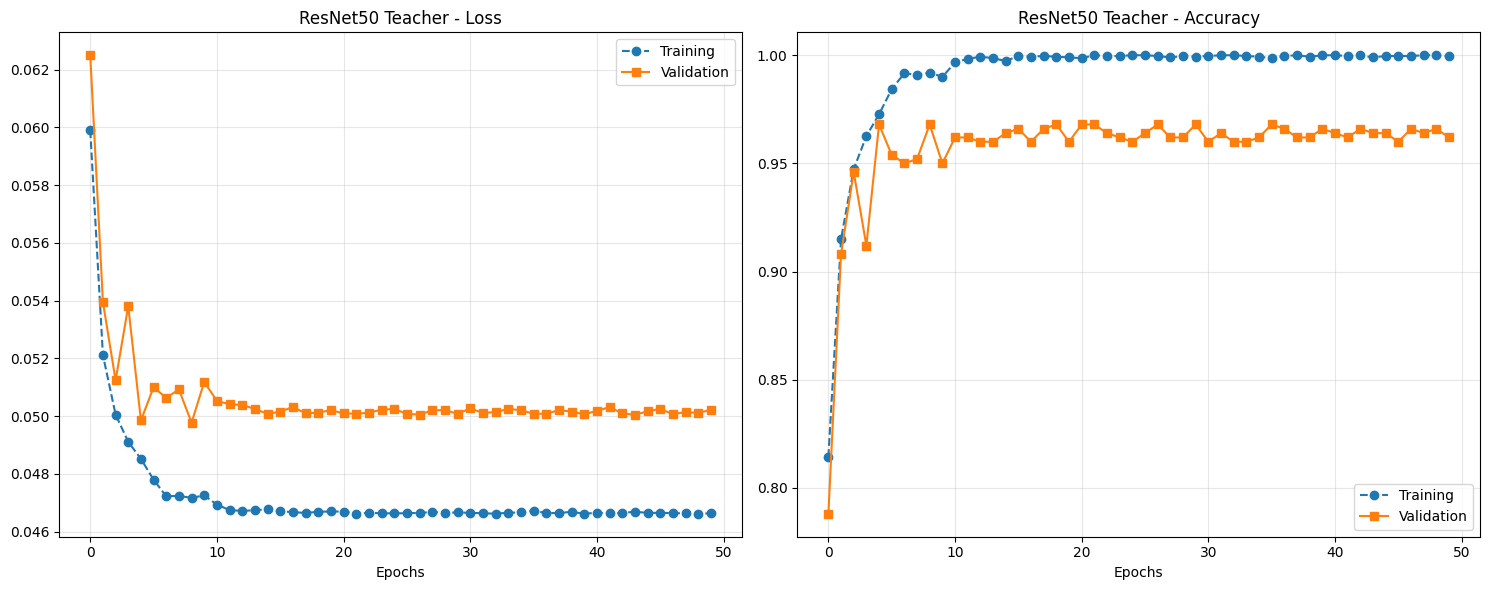

In [ ]:
# 4. Teacher Model initialization
class ResNetWrapper(nn.Module):
    def __init__(self, model):
        super(ResNetWrapper, self).__init__()
        self.model = model

    def forward(self, x):
        return nn.functional.softmax(self.model(x), dim=1)

resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Linear(resnet.fc.in_features, OUT_SIZE)
teacher_model = ResNetWrapper(resnet).to(device)

# Training configurations
EPOCHS = 50
LR = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(teacher_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Training Loop
best_model = deepcopy(teacher_model)
best_acc = 0
train_loss, train_acc, val_loss, val_acc = [], [], [], []

for epoch in range(1, EPOCHS + 1):
    teacher_model.train()
    diff, acc, total = 0, 0, 0

    for data, target in train_dl:
        optimizer.zero_grad()
        data, target = data.to(device), target.to(device)

        out = teacher_model(data)
        loss = criterion(out, target)

        loss.backward()
        optimizer.step()

        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)

    train_loss.append(diff / total)
    train_acc.append(acc / total)

    # Validation Phase
    teacher_model.eval()
    diff, acc, total = 0, 0, 0

    with torch.no_grad():
        for data, target in val_dl:
            data, target = data.to(device), target.to(device)
            out = teacher_model(data)
            loss = criterion(out, target)
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)

    val_loss.append(diff / total)
    val_acc.append(acc / total)

    # Save best model
    if val_acc[-1] >= best_acc:
        best_acc = val_acc[-1]
        best_model = deepcopy(teacher_model)

    scheduler.step()
    print(f"Epoch {epoch} | Train Loss: {train_loss[-1]:.4f} | Train Acc: {train_acc[-1]:.4f} | Val Loss: {val_loss[-1]:.4f} | Val Acc: {val_acc[-1]:.4f}")

plot_training_history(train_loss, val_loss, train_acc, val_acc, title="ResNet50 Teacher")

# Student Model Setup and Training (Knowledge Distillation)

In [ ]:
# 5. Student Model Initialization (Lighter ResNet18)
student_base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
student_base.fc = nn.Linear(student_base.fc.in_features, OUT_SIZE)
student_model = ResNetWrapper(student_base).to(device)

# The teacher is the previously trained best_model
teacher_model = best_model
teacher_model.eval() # The teacher model no longer updates

optimizer_student = torch.optim.Adam(student_model.parameters(), lr=0.001)
EPOCHS_DISTILL = 50

for epoch in range(1, EPOCHS_DISTILL + 1):
    student_model.train()
    total_loss = 0

    for data, target in train_dl:
        data, target = data.to(device), target.to(device)
        optimizer_student.zero_grad()

        # 1. Teacher output (raw logits, no gradients)
        with torch.no_grad():
            teacher_preds = teacher_model.model(data)

        # 2. Student output (raw logits)
        student_preds = student_model.model(data)

        # 3. Combined Distillation Loss
        loss = distillation_loss(student_preds, target, teacher_preds, T=3.0, alpha=0.7)

        loss.backward()
        optimizer_student.step()
        total_loss += loss.item()

    print(f"Epoch {epoch} | Distillation Loss: {total_loss/len(train_dl):.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


Epoch 1 | Distillation Loss: 2.6539
Epoch 2 | Distillation Loss: 1.6076
Epoch 3 | Distillation Loss: 0.9910
Epoch 4 | Distillation Loss: 0.8488
Epoch 5 | Distillation Loss: 0.5108
Epoch 6 | Distillation Loss: 0.3304
Epoch 7 | Distillation Loss: 0.4675
Epoch 8 | Distillation Loss: 0.4389
Epoch 9 | Distillation Loss: 0.3188
Epoch 10 | Distillation Loss: 0.2704
Epoch 11 | Distillation Loss: 0.2690
Epoch 12 | Distillation Loss: 0.2252
Epoch 13 | Distillation Loss: 0.1363
Epoch 14 | Distillation Loss: 0.0853
Epoch 15 | Distillation Loss: 0.0766
Epoch 16 | Distillation Loss: 0.0695
Epoch 17 | Distillation Loss: 0.0611
Epoch 18 | Distillation Loss: 0.0548
Epoch 19 | Distillation Loss: 0.0480
Epoch 20 | Distillation Loss: 0.0456
Epoch 21 | Distillation Loss: 0.0445
Epoch 22 | Distillation Loss: 0.0375
Epoch 23 | Distillation Loss: 0.0389
Epoch 24 | Distillation Loss: 0.0325
Epoch 25 | Distillation Loss: 0.0338
Epoch 26 | Distillation Loss: 0.0337
Epoch 27 | Distillation Loss: 1.3194
Epoch 28 |

In [ ]:

# Save Model Weights

import os

# Création d'un dossier pour ranger les modèles si vous le souhaitez
os.makedirs("saved_models", exist_ok=True)

# Sauvegarde du Teacher (ResNet-50)
teacher_path = "saved_models/teacher_resnet50_best.pth"
torch.save(teacher_model.state_dict(), teacher_path)
print(f"Poids du Teacher sauvegardés avec succès dans : {teacher_path}")

# Sauvegarde du Student (ResNet-18)
student_path = "saved_models/student_resnet18_distilled.pth"
torch.save(student_model.state_dict(), student_path)
print(f"Poids du Student sauvegardés avec succès dans : {student_path}")

Poids du Teacher sauvegardés avec succès dans : saved_models/teacher_resnet50_best.pth
Poids du Student sauvegardés avec succès dans : saved_models/student_resnet18_distilled.pth


# Model Evaluation & Inference


--- Classification Report ---
              precision    recall  f1-score   support

   pituitary       0.98      0.98      0.98       129
     notumor       1.00      0.98      0.99       126
  meningioma       0.98      0.99      0.99       131
      glioma       0.97      0.99      0.98       114

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



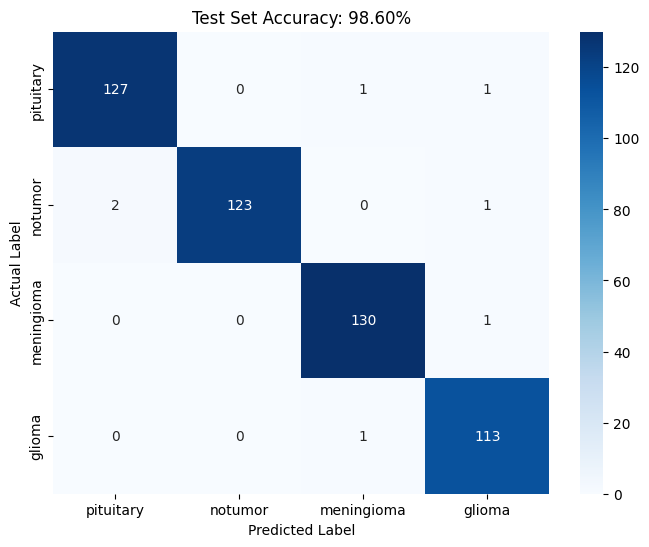

Starting Student Model evaluation on test set...

--- Student Model Classification Report (ResNet18) ---
              precision    recall  f1-score   support

   pituitary       0.95      0.99      0.97       129
     notumor       0.98      0.95      0.97       126
  meningioma       0.98      0.94      0.96       131
      glioma       0.96      0.99      0.97       114

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



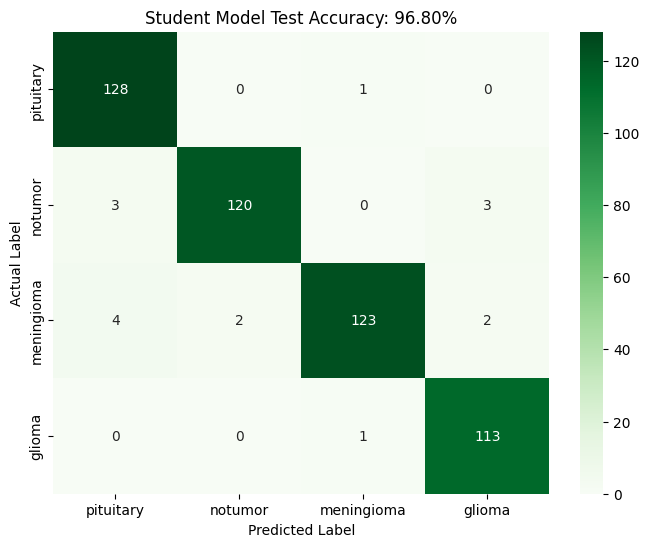

In [ ]:
# 6. Evaluation
def predict(img_path, model):
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(np.array(img)).view(1, 3, 224, 224).to(device)

    model.eval()
    with torch.no_grad():
        out = model(img_tensor)

    pred_idx = out.argmax(1).item()
    confidence = round(out[0][pred_idx].item() * 100, 2)
    return pred_idx, confidence

# Evaluate using the chosen model (using best_model / teacher here as per original code)
truth = []
preds = []

np.random.shuffle(test)

for i in range(test.shape[0]):
    truth.append(test[i, 1])
    pred, _ = predict(test[i, 0], best_model)
    preds.append(pred)

score = accuracy_score(truth, preds)
label_names = [index_label[i] for i in range(OUT_SIZE)]

print("\n--- Classification Report ---")
print(classification_report(truth, preds, target_names=label_names))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(truth, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title(f"Test Set Accuracy: {score:.2%}")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()



# Student evaluation

# 7. Student Model Evaluation
truth_student = []
preds_student = []

print("Starting Student Model evaluation on test set...")

for i in range(test.shape[0]):
    img_path, label = test[i, 0], test[i, 1]

    # Image preprocessing
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(np.array(img)).view(1, 3, 224, 224).to(device)

    # Student Inference
    student_model.eval()
    with torch.no_grad():
        # We use the wrapper which includes the softmax
        out = student_model(img_tensor)

    pred_idx = out.argmax(1).item()

    truth_student.append(label)
    preds_student.append(pred_idx)

# Calculation of metrics
score_student = accuracy_score(truth_student, preds_student)
label_names = [index_label[i] for i in range(OUT_SIZE)]

print("\n--- Student Model Classification Report (ResNet18) ---")
print(classification_report(truth_student, preds_student, target_names=label_names))

# Plotting the Student Confusion Matrix
plt.figure(figsize=(8, 6))
cm_student = confusion_matrix(truth_student, preds_student)
sns.heatmap(cm_student, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names)

plt.title(f"Student Model Test Accuracy: {score_student:.2%}")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Metric               | Teacher (ResNet50)   | Student (ResNet18)  
-----------------------------------------------------------------
Parameters           | 23.52             M | 11.18             M
Latency (ms/img)     | 6.60               | 2.63              
Throughput (FPS)     | 151.49             | 379.84            


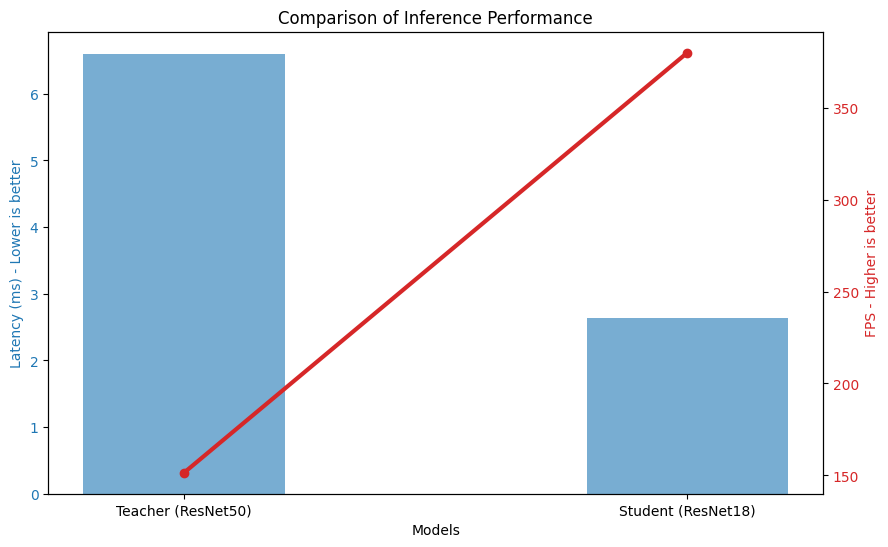

In [ ]:
import time

# 8. Inference Speed & Model Complexity Comparison
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_inference_speed(model, device, input_size=(1, 3, 224, 224), iterations=100):
    model.eval()
    dummy_input = torch.randn(*input_size).to(device)

    # Warm-up (to initialize CUDA kernels)
    for _ in range(10):
        _ = model(dummy_input)

    torch.cuda.synchronize() if device == "cuda" else None
    start_time = time.time()

    with torch.no_grad():
        for _ in range(iterations):
            _ = model(dummy_input)
            if device == "cuda":
                torch.cuda.synchronize()

    end_time = time.time()
    total_time = end_time - start_time
    avg_latency = (total_time / iterations) * 1000 # in milliseconds
    fps = iterations / total_time

    return avg_latency, fps

# Calculations
params_teacher = count_parameters(teacher_model)
params_student = count_parameters(student_model)

latency_t, fps_t = measure_inference_speed(teacher_model, device)
latency_s, fps_s = measure_inference_speed(student_model, device)

# Results Summary
print(f"{'Metric':<20} | {'Teacher (ResNet50)':<20} | {'Student (ResNet18)':<20}")
print("-" * 65)
print(f"{'Parameters':<20} | {params_teacher/1e6:<18.2f}M | {params_student/1e6:<18.2f}M")
print(f"{'Latency (ms/img)':<20} | {latency_t:<18.2f} | {latency_s:<18.2f}")
print(f"{'Throughput (FPS)':<20} | {fps_t:<18.2f} | {fps_s:<18.2f}")

# Visualization
labels = ['Teacher (ResNet50)', 'Student (ResNet18)']
latencies = [latency_t, latency_s]
fps_values = [fps_t, fps_s]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Latency Bar Chart
color = 'tab:blue'
ax1.set_xlabel('Models')
ax1.set_ylabel('Latency (ms) - Lower is better', color=color)
ax1.bar(labels, latencies, color=color, alpha=0.6, width=0.4, label='Latency')
ax1.tick_params(axis='y', labelcolor=color)

# FPS Line Chart (Twin axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('FPS - Higher is better', color=color)
ax2.plot(labels, fps_values, color=color, marker='o', linewidth=3, label='FPS')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparison of Inference Performance')
plt.show()